In [ ]:
from __future__ import annotations
import re
import random
import math
from dataclasses import dataclass, field
from typing import List, Dict, Any, Optional

import numpy as np
from sentence_transformers import SentenceTransformer
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch
import torch.nn.functional as F

# ------------------------------
# Config
# ------------------------------

DEFAULT_EMBED_MODEL = "BAAI/bge-m3"
DEFAULT_NLI_MODEL = "cross-encoder/nli-deberta-v3-base"

TORCH_DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

VALID_LABELS = [
    "SUPPORTED", "REFUTED",
    "PARTLY SUPPORTED", "PARTLY REFUTED",
    "UNVERIFIABLE",
]

@dataclass
class BlockWeights:
    coherence: float = 0.25
    concision: float = 0.25
    evidence: float = 0.25
    verdict: float = 0.25

@dataclass
class RandomWalkConfig:
    order_n: int = 2
    n_walks: int = 256
    max_len: Optional[int] = None
    temperature: float = 0.5
    self_loops: bool = False

@dataclass
class GranularityConfig:
    ideal_steps_low: int = 4
    ideal_steps_high: int = 5
    max_sent_per_step: int = 3
    max_seq_len: int = 256   # ✅ added

@dataclass
class EvidenceConfig:
    sim_threshold: float = 0.45
    entail_weight: float = 0.5
    contra_weight: float = 0.5

@dataclass
class EvaluatorConfig:
    embed_model_name: str = DEFAULT_EMBED_MODEL
    nli_model_name: str = DEFAULT_NLI_MODEL
    random_walk: RandomWalkConfig = field(default_factory=RandomWalkConfig)
    granularity: GranularityConfig = field(default_factory=GranularityConfig)
    evidence: EvidenceConfig = field(default_factory=EvidenceConfig)
    weights: BlockWeights = field(default_factory=BlockWeights)

# ------------------------------
# Preprocessing
# ------------------------------

def normalize_reasoning_steps(reasoning_trace: str) -> List[str]:
    steps = []
    for line in reasoning_trace.splitlines():
        m = re.match(r"\s*R(\d+)\s*:\s*(.*)", line)
        if m:
            steps.append(m.group(2).strip())
    return steps

# ------------------------------
# Embedding + NLI helpers
# ------------------------------

class EmbeddingBackend:
    def __init__(self, model_name: str):
        self.model = SentenceTransformer(model_name)

    def encode(self, texts: List[str]) -> np.ndarray:
        return self.model.encode(
            texts, convert_to_numpy=True,
            normalize_embeddings=True, batch_size=32
        )

    @staticmethod
    def cosine_sim(a: np.ndarray, b: np.ndarray) -> np.ndarray:
        return np.matmul(a, b.T)

class NLICrossEncoder:
    def __init__(self, model_name: str):
        self.tokenizer = AutoTokenizer.from_pretrained(model_name)
        self.model = AutoModelForSequenceClassification.from_pretrained(model_name).to(TORCH_DEVICE)
        self.model.eval()
        self.label_ix = {"contradiction": 0, "entailment": 1, "neutral": 2}

    @torch.no_grad()
    def probs(self, premise: str, hypothesis: str) -> Dict[str, float]:
        tok = self.tokenizer(premise, hypothesis, return_tensors="pt", truncation=True, padding=True, max_length=512)
        tok = {k: v.to(TORCH_DEVICE) for k, v in tok.items()}
        out = self.model(**tok)
        pr = F.softmax(out.logits, dim=-1).detach().cpu().numpy()[0]
        return {
            "contradiction": float(pr[self.label_ix["contradiction"]]),
            "entailment": float(pr[self.label_ix["entailment"]]),
            "neutral": float(pr[self.label_ix["neutral"]]),
        }

# # ------------------------------
# # Block 1: Coherence
# # ------------------------------

# def build_transition_matrix(step_embs: np.ndarray, order_n: int, temperature: float, self_loops: bool) -> np.ndarray:
#     S = EmbeddingBackend.cosine_sim(step_embs, step_embs)
#     np.fill_diagonal(S, -1.0 if not self_loops else S.diagonal())
#     logits = S / max(temperature, 1e-6)
#     P = np.exp(logits - logits.max(axis=1, keepdims=True))
#     return P / P.sum(axis=1, keepdims=True)

# def simulate_walks(steps: List[str], P: np.ndarray, cfg: RandomWalkConfig) -> float:
#     k = len(steps)
#     indices = list(range(k))
#     monotone_hits = 0

#     for _ in range(cfg.n_walks):
#         curr = random.choice(indices)
#         path = [curr]
#         max_len = cfg.max_len or k
#         while len(path) < max_len:
#             row = P[curr].copy()
#             for j in indices:
#                 if j in path: row[j] *= 0.8
#                 if j > curr: row[j] *= 1.05
#             row = np.maximum(row, 0)
#             if row.sum() <= 0: break
#             row /= row.sum()
#             nxt = np.random.choice(indices, p=row)
#             path.append(nxt)
#             curr = nxt
#         if all(path[i] <= path[i+1] for i in range(len(path)-1)):
#             monotone_hits += 1

#     return monotone_hits / max(cfg.n_walks, 1)


# ------------------------------
# Block 1: Coherence
# ------------------------------

def build_transition_matrix(step_embs: np.ndarray, order_n: int, temperature: float, self_loops: bool) -> np.ndarray:
    S = EmbeddingBackend.cosine_sim(step_embs, step_embs)
    np.fill_diagonal(S, -1.0 if not self_loops else S.diagonal())
    logits = S / max(temperature, 1e-6)
    P = np.exp(logits - logits.max(axis=1, keepdims=True))
    return P / P.sum(axis=1, keepdims=True)


def simulate_walks(steps: List[str], P: np.ndarray, cfg: RandomWalkConfig) -> float:
    k = len(steps)
    indices = list(range(k))
    walk_scores = []

    # restrict starting pool to first third
    start_pool = [i for i in indices if i < max(1, k // 3)]

    for _ in range(cfg.n_walks):
        curr = random.choice(start_pool)
        path = [curr]
        max_len = cfg.max_len or k

        while len(path) < max_len:
            row = P[curr].copy()
            for j in indices:
                if j in path:
                    row[j] *= 0.75   # discourage repeats
            row = np.maximum(row, 0)
            if row.sum() <= 0:
                break
            row /= row.sum()
            nxt = np.random.choice(indices, p=row)
            path.append(nxt)
            curr = nxt

        # ---- scoring: reward i -> i±1 transitions, ignore oscillations ----
        if len(path) > 1:
            rewards = 0
            for i in range(len(path) - 1):
                step = path[i+1] - path[i]

                if step in (-1, 1):  # forward or backward
                    if i > 0:
                        prev_step = path[i] - path[i-1]
                        if prev_step == -step:
                            continue  # ignore oscillation
                    rewards += 1

            score = rewards / (len(path) - 1)
        else:
            score = 0.0

        walk_scores.append(score)

    base_score = float(np.mean(walk_scores)) if walk_scores else 0.0

    # ✅ CHANGE: incremental short-trace penalty
    if k < granularity_cfg.ideal_steps_low:
        factor = (k / granularity_cfg.ideal_steps_low)  # smaller k → smaller factor
        base_score *= factor

    return base_score


# ------------------------------
# Block 2: Concision
# ------------------------------

def concision_score_only(steps: List[str], cfg: GranularityConfig, nli_model=None, tokenizer=None, device="cpu") -> float:
    if nli_model is None or tokenizer is None or len(steps) <= 1:
        return 1.0

    penalties = []
    for i in range(len(steps) - 1):
        premise, hypothesis = steps[i], steps[i+1]

        # Forward
        inputs_fw = tokenizer(premise, hypothesis, return_tensors="pt", truncation=True, max_length=cfg.max_seq_len).to(device)
        with torch.no_grad():
            probs_fw = torch.softmax(nli_model(**inputs_fw).logits, dim=-1).cpu().numpy()[0]
        contra_fw, entail_fw, neut_fw = probs_fw[0], probs_fw[1], probs_fw[2]

        # Backward
        inputs_bw = tokenizer(hypothesis, premise, return_tensors="pt", truncation=True, max_length=cfg.max_seq_len).to(device)
        with torch.no_grad():
            probs_bw = torch.softmax(nli_model(**inputs_bw).logits, dim=-1).cpu().numpy()[0]
        contra_bw, entail_bw, neut_bw = probs_bw[0], probs_bw[1], probs_bw[2]

        if entail_fw > 0.7 and entail_bw > 0.7:
            penalties.append(0.0)
        elif neut_fw > 0.5 and neut_bw > 0.5:
            penalties.append(1.0)
        elif contra_fw > 0.5 or contra_bw > 0.5:
            penalties.append(0.3)
        else:
            penalties.append(0.7)


    base_score = sum(penalties) / len(penalties)

    # ✅ CHANGE: incremental short-trace penalty
    if len(steps) < cfg.ideal_steps_low:
        factor = (len(steps) / cfg.ideal_steps_low)  # smaller len → smaller factor
        base_score *= factor

    return base_score


# ------------------------------
# Block 3: Evidence Matching
# ------------------------------

def evidence_alignment_score(steps: List[str], evidences: List[str],
                             embed: EmbeddingBackend,
                             nli: Optional[NLICrossEncoder],
                             cfg: EvidenceConfig) -> float:
    if not evidences:
        return 0.5  # neutral if no evidence given

    step_embs = embed.encode(steps)
    ev_embs = embed.encode(evidences)

    sim_matrix = EmbeddingBackend.cosine_sim(step_embs, ev_embs)

    # For each step, find max matching evidence
    align_scores = []
    for i, step in enumerate(steps):
        j = np.argmax(sim_matrix[i])
        sim_val = sim_matrix[i, j]
        score = 0.0
        if sim_val >= cfg.sim_threshold:
            score = 0.5  # base score for similarity
            if nli is not None:
                nli_probs = nli.probs(evidences[j], step)
                score += cfg.entail_weight * nli_probs["entailment"]
                score -= cfg.contra_weight * nli_probs["contradiction"]
                score = max(0.0, min(1.0, score))
        align_scores.append(score)

    return sum(align_scores) / max(len(align_scores), 1)


# ------------------------------
# Block 4: Verdict Scorer (Differential / ODE-based)(Stepwise NLI = internal reasoning consistency.

#Final NLI = claim relevance.

#Output = combination of trajectory and claim matching.)
# ------------------------------


class VerdictScorerDifferential:
    """
    ODE-based belief updater for verdict scoring.
    Integrates dp/dt = r * (S(t)-0.5) * p * (1-p) over reasoning steps,
    where S(t) is now computed only from entailment and contradiction
    signals between consecutive reasoning steps.
    """

    def __init__(self, nli_model: NLICrossEncoder, embed: EmbeddingBackend, cfg=None):
        self.nli = nli_model
        self.embed = embed
        if cfg is None:
            class C: pass
            cfg = C()
        self.r = getattr(cfg, "ode_r", 2.0)       # ODE growth rate
        self.dt = getattr(cfg, "ode_dt", 1.0)     # step size per reasoning step
        self.eps = 1e-6

    def _compute_per_step_signals(self, steps: List[str]):
        """
        Returns entail_list and contra_list for each step i,
        based on NLI between R_{i-1} and R_i.
        For R0, signals are set to 0 (no previous step).
        """
        n = len(steps)
        entail_list, contra_list = [], []
        for i in range(n):
            if i == 0:
                entail_list.append(0.0)
                contra_list.append(0.0)
            else:
                probs = self.nli.probs(steps[i-1], steps[i])
                entail_list.append(float(probs.get("entailment", 0.0)))
                contra_list.append(float(probs.get("contradiction", 0.0)))
        return entail_list, contra_list

    def _ode_rhs(self, p: float, S: float) -> float:
        """RHS of ODE: dp/dt = r * (S - 0.5) * p * (1-p)"""
        return self.r * (S - 0.5) * p * (1.0 - p)

    def _rk4_step(self, p: float, S: float, dt: float) -> float:
        k1 = self._ode_rhs(p, S)
        k2 = self._ode_rhs(p + 0.5*dt*k1, S)
        k3 = self._ode_rhs(p + 0.5*dt*k2, S)
        k4 = self._ode_rhs(p + dt*k3, S)
        p_next = p + (dt/6.0)*(k1 + 2*k2 + 2*k3 + k4)
        return float(max(self.eps, min(1.0 - self.eps, p_next)))

    def score(self,
              reasoning_steps: List[str],
              claim: str,
              evidences: List[str],
              gold_label: str,
              integrator: str = "rk4") -> float:
        if not reasoning_steps or len(reasoning_steps) < 1:
            return 0.0

        entail_list, contra_list = self._compute_per_step_signals(reasoning_steps)
        p = 0.5  # initial belief

        for i in range(len(reasoning_steps)):
            S_raw = entail_list[i] - contra_list[i]  # ✅ simplified: only entail vs contra
            S = max(0.0, min(1.0, (S_raw + 1.0) / 2.0))  # normalize to [0,1]
            if integrator == "rk4":
                p = self._rk4_step(p, S, self.dt)
            else:
                dp = self._ode_rhs(p, S) * self.dt
                p = float(max(self.eps, min(1.0 - self.eps, p + dp)))

        final_probs = (
    self.nli.probs(reasoning_steps[-1], claim)
    if self.nli
    else {"entailment": 0.0, "contradiction": 0.0, "neutral": 0.0})

    p_e = final_probs.get("entailment", 0.0)
    p_c = final_probs.get("contradiction", 0.0)
    p_n = final_probs.get("neutral", 0.0)

    label_mapping = {
        "SUPPORTED": p_e,
        "REFUTED": p_c,
        "PARTLY SUPPORTED": 4*p_e * (1 - p_e),
        "PARTLY REFUTED": 4*p_c * (1 - p_c),
        "UNVERIFIABLE": p_n,
    }

    scores = {lbl: p * val for lbl, val in label_mapping.items()}

    final_score = scores.get(gold_label, 0.0)
    return float(max(0.0, min(1.0, final_score)))


# ------------------------------
# Full Evaluation Aggregator (Using ODE-based Verdict Scorer)
# ------------------------------

def evaluate_reasoning_trace(claim: str,
                              reasoning_trace: str,
                              evidences: List[str],
                              gold_label: str,
                              cfg: EvaluatorConfig) -> Dict[str, Any]:
    """
    Evaluate a reasoning trace against multiple criteria:
    - Coherence (Block 1)
    - Concision (Block 2, granularity removed)
    - Evidence Alignment (Block 3)
    - Verdict Consistency (Block 4, ODE-based)

    Returns component scores and a weighted total score.
    """

    # Normalize steps
    steps = normalize_reasoning_steps(reasoning_trace)

    # Backends
    embed_backend = EmbeddingBackend(cfg.embed_model_name)
    nli_backend = NLICrossEncoder(cfg.nli_model_name)

    # --- Block 1: Coherence only ---
    step_embs = embed_backend.encode(steps)
    P = build_transition_matrix(
        step_embs,
        cfg.random_walk.order_n,
        cfg.random_walk.temperature,
        cfg.random_walk.self_loops
    )
    coherence_score = simulate_walks(steps, P, cfg.random_walk)

    # --- Block 2: Concision only ---
    concision_score = concision_score_only(
        steps, cfg.granularity, nli_backend.model, nli_backend.tokenizer
    )

    # --- Block 3: Evidence alignment ---
    evidence_score = evidence_alignment_score(
        steps, evidences, embed_backend, nli_backend, cfg.evidence
    )

    # --- Block 4: Verdict consistency (ODE-based) ---
    verdict_scorer = VerdictScorerDifferential(nli_backend, embed_backend, cfg)
    verdict_score = verdict_scorer.score(steps, claim, evidences, gold_label)

    # Weighted aggregation
    total_score = (
        cfg.weights.coherence * coherence_score +
        cfg.weights.concision * concision_score +
        cfg.weights.evidence * evidence_score +
        cfg.weights.verdict * verdict_score
    )

    return {
        "steps": steps,
        "coherence_score": coherence_score,
        "concision_score": concision_score,
        "evidence_score": evidence_score,
        "verdict_score": verdict_score,
        "total_score": total_score,
    }

SyntaxError: 'return' outside function (ipython-input-2846251154.py, line 378)

 step  S_i (after step i)  p_ODE  p_multiplication
    0                 NaN 0.5000            0.5000
    1               0.700 0.5987            0.3750
    2               0.800 0.7310            0.3281
    3               0.650 0.7858            0.2256
    4               0.750 0.8581            0.1755
    5               0.650 0.8909            0.1170
    6               0.925 0.9500            0.1108
    7               0.650 0.9625            0.0739


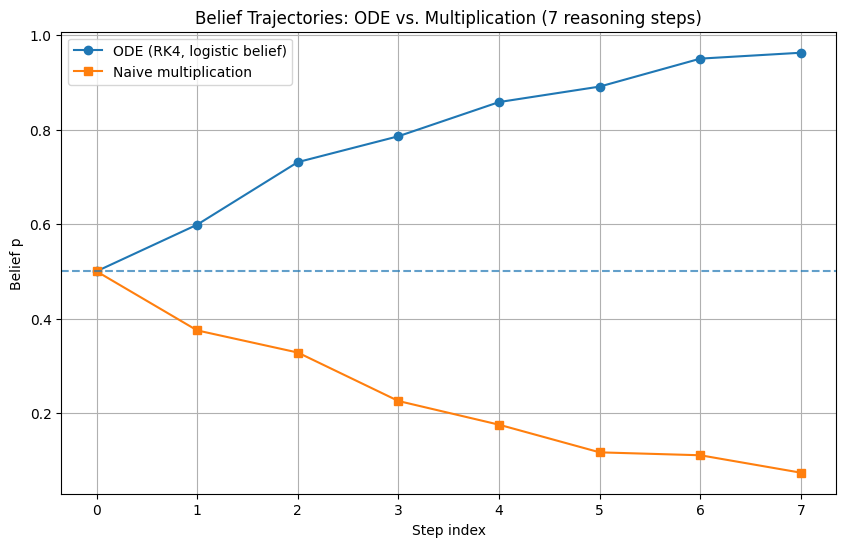

In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Synthetic NLI signals for 7 reasoning steps: (entail, contra, neutral)
nli_signals = [
    (0.6, 0.2, 0.2),
    (0.7, 0.1, 0.2),
    (0.55, 0.25, 0.2),
    (0.7, 0.2, 0.1),
    (0.6, 0.3, 0.1),
    (0.9, 0.05, 0.05),
    (0.6, 0.3, 0.1),
]

def ode_rhs(p, S, r=2.0):
    return r * (S - 0.5) * p * (1 - p)

def rk4_step(p, S, dt=1.0, r=2.0):
    k1 = ode_rhs(p, S, r)
    k2 = ode_rhs(p + 0.5*dt*k1, S, r)
    k3 = ode_rhs(p + 0.5*dt*k2, S, r)
    k4 = ode_rhs(p + dt*k3, S, r)
    return p + (dt/6.0)*(k1 + 2*k2 + 2*k3 + k4)

def run_ode(nli_signals, r=2.0, dt=1.0, p0=0.5):
    p_values = [p0]
    p = p0
    S_values = []
    for e, c, _ in nli_signals:
        S_raw = e - c
        S = (S_raw + 1) / 2.0
        S_values.append(S)
        p = rk4_step(p, S, dt, r)
        p_values.append(p)
    return np.array(p_values), np.array(S_values)

def run_multiplication(nli_signals, p0=0.5):
    p_values = [p0]
    p = p0
    for e, c, _ in nli_signals:
        denom = (e + c)
        signal = (e / denom) if denom > 0 else 0.5
        p *= signal
        p_values.append(p)
    return np.array(p_values)

if __name__ == "__main__":
    ode_traj, S_vals = run_ode(nli_signals, r=2.0, dt=1.0, p0=0.5)
    mult_traj = run_multiplication(nli_signals, p0=0.5)

    steps = np.arange(0, len(nli_signals) + 1)
    table = pd.DataFrame({
        "step": steps,
        "S_i (after step i)": np.concatenate([[np.nan], S_vals]),
        "p_ODE": ode_traj,
        "p_multiplication": mult_traj,
    })
    print(table.round(4).to_string(index=False))

    plt.figure(figsize=(10,6))
    plt.plot(steps, ode_traj, marker="o", label="ODE (RK4, logistic belief)")
    plt.plot(steps, mult_traj, marker="s", label="Naive multiplication")
    plt.axhline(0.5, linestyle="--", alpha=0.7)
    plt.title("Belief Trajectories: ODE vs. Multiplication (7 reasoning steps)")
    plt.xlabel("Step index")
    plt.ylabel("Belief p")
    plt.legend()
    plt.grid(True)
    plt.show()


 step  S_i (ODE)  p_ODE  p_multiplication
    0        NaN 0.5000            0.5000
    1      0.700 0.5987            0.7500
    2      0.800 0.7310            0.9545
    3      0.650 0.7858            0.9788
    4      0.750 0.8581            0.9939
    5      0.650 0.8909            0.9969
    6      0.925 0.9500            0.9998
    7      0.650 0.9625            0.9999


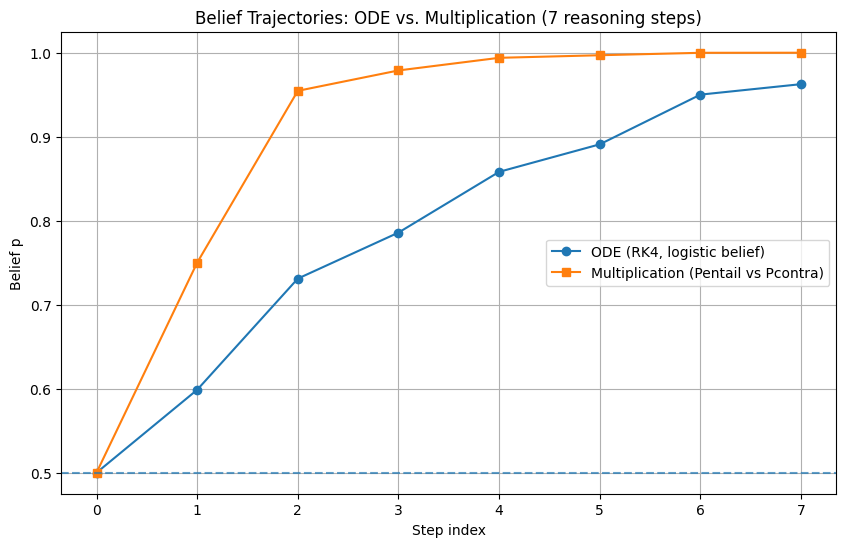

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Synthetic NLI signals for 7 reasoning steps: (entail, contra, neutral)
nli_signals = [
    (0.6, 0.2, 0.2),
    (0.7, 0.1, 0.2),
    (0.55, 0.25, 0.2),
    (0.7, 0.2, 0.1),
    (0.6, 0.3, 0.1),
    (0.9, 0.05, 0.05),
    (0.6, 0.3, 0.1),
]

# ---------------- ODE / RK4 method ----------------
def ode_rhs(p, S, r=2.0):
    return r * (S - 0.5) * p * (1 - p)

def rk4_step(p, S, dt=1.0, r=2.0):
    k1 = ode_rhs(p, S, r)
    k2 = ode_rhs(p + 0.5*dt*k1, S, r)
    k3 = ode_rhs(p + 0.5*dt*k2, S, r)
    k4 = ode_rhs(p + dt*k3, S, r)
    return p + (dt/6.0)*(k1 + 2*k2 + 2*k3 + k4)

def run_ode(nli_signals, r=2.0, dt=1.0, p0=0.5):
    p_values = [p0]
    p = p0
    S_values = []
    for e, c, _ in nli_signals:
        S_raw = e - c
        S = (S_raw + 1) / 2.0
        S_values.append(S)
        p = rk4_step(p, S, dt, r)
        p_values.append(p)
    return np.array(p_values), np.array(S_values)

# ---------------- Multiplicative (Bayesian style) ----------------
def run_multiplication(nli_signals, p0=0.5):
    Pentail, Pcontra = 1.0, 1.0
    p_values = [p0]

    for e, c, _ in nli_signals:
        Pentail *= e
        Pcontra *= c if c > 0 else 1e-6  # avoid zero collapse
        denom = Pentail + Pcontra
        p = Pentail / denom if denom > 0 else 0.5
        p_values.append(p)

    return np.array(p_values)

# ---------------- Main ----------------
if __name__ == "__main__":
    ode_traj, S_vals = run_ode(nli_signals, r=2.0, dt=1.0, p0=0.5)
    mult_traj = run_multiplication(nli_signals, p0=0.5)

    steps = np.arange(0, len(nli_signals) + 1)
    table = pd.DataFrame({
        "step": steps,
        "S_i (ODE)": np.concatenate([[np.nan], S_vals]),
        "p_ODE": ode_traj,
        "p_multiplication": mult_traj,
    })
    print(table.round(4).to_string(index=False))

    plt.figure(figsize=(10,6))
    plt.plot(steps, ode_traj, marker="o", label="ODE (RK4, logistic belief)")
    plt.plot(steps, mult_traj, marker="s", label="Multiplication (Pentail vs Pcontra)")
    plt.axhline(0.5, linestyle="--", alpha=0.7)
    plt.title("Belief Trajectories: ODE vs. Multiplication (7 reasoning steps)")
    plt.xlabel("Step index")
    plt.ylabel("Belief p")
    plt.legend()
    plt.grid(True)
    plt.show()


 step  S_i (ODE)  p_ODE  p_multiplication
    0        NaN 0.5000            0.5000
    1      0.925 0.7005            0.9474
    2      0.875 0.8319            0.9935
    3      0.965 0.9258            0.9999
    4      0.925 0.9667            1.0000
    5      0.905 0.9848            1.0000
    6      0.940 0.9936            1.0000
    7      0.925 0.9972            1.0000


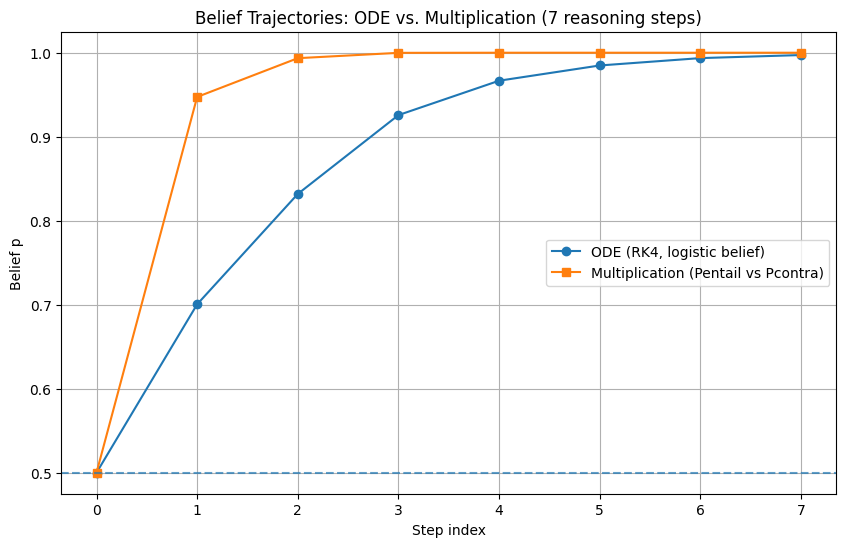

In [ ]:
#consistently supportive

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Synthetic NLI signals for 7 reasoning steps: (entail, contra, neutral)
nli_signals = [
    (0.9, 0.05, 0.05),
    (0.85, 0.1, 0.05),
    (0.95, 0.02, 0.03),
    (0.9, 0.05, 0.05),
    (0.88, 0.07, 0.05),
    (0.92, 0.04, 0.04),
    (0.9, 0.05, 0.05),
]

# ---------------- ODE / RK4 method ----------------
def ode_rhs(p, S, r=2.0):
    return r * (S - 0.5) * p * (1 - p)

def rk4_step(p, S, dt=1.0, r=2.0):
    k1 = ode_rhs(p, S, r)
    k2 = ode_rhs(p + 0.5*dt*k1, S, r)
    k3 = ode_rhs(p + 0.5*dt*k2, S, r)
    k4 = ode_rhs(p + dt*k3, S, r)
    return p + (dt/6.0)*(k1 + 2*k2 + 2*k3 + k4)

def run_ode(nli_signals, r=2.0, dt=1.0, p0=0.5):
    p_values = [p0]
    p = p0
    S_values = []
    for e, c, _ in nli_signals:
        S_raw = e - c
        S = (S_raw + 1) / 2.0
        S_values.append(S)
        p = rk4_step(p, S, dt, r)
        p_values.append(p)
    return np.array(p_values), np.array(S_values)

# ---------------- Multiplicative (Bayesian style) ----------------
def run_multiplication(nli_signals, p0=0.5):
    Pentail, Pcontra = 1.0, 1.0
    p_values = [p0]

    for e, c, _ in nli_signals:
        Pentail *= e
        Pcontra *= c if c > 0 else 1e-6  # avoid zero collapse
        denom = Pentail + Pcontra
        p = Pentail / denom if denom > 0 else 0.5
        p_values.append(p)

    return np.array(p_values)

# ---------------- Main ----------------
if __name__ == "__main__":
    ode_traj, S_vals = run_ode(nli_signals, r=2.0, dt=1.0, p0=0.5)
    mult_traj = run_multiplication(nli_signals, p0=0.5)

    steps = np.arange(0, len(nli_signals) + 1)
    table = pd.DataFrame({
        "step": steps,
        "S_i (ODE)": np.concatenate([[np.nan], S_vals]),
        "p_ODE": ode_traj,
        "p_multiplication": mult_traj,
    })
    print(table.round(4).to_string(index=False))

    plt.figure(figsize=(10,6))
    plt.plot(steps, ode_traj, marker="o", label="ODE (RK4, logistic belief)")
    plt.plot(steps, mult_traj, marker="s", label="Multiplication (Pentail vs Pcontra)")
    plt.axhline(0.5, linestyle="--", alpha=0.7)
    plt.title("Belief Trajectories: ODE vs. Multiplication (7 reasoning steps)")
    plt.xlabel("Step index")
    plt.ylabel("Belief p")
    plt.legend()
    plt.grid(True)
    plt.show()


 step  S_i (ODE)  p_ODE  p_multiplication
    0        NaN 0.5000            0.5000
    1      0.075 0.2995            0.0526
    2      0.125 0.1681            0.0065
    3      0.035 0.0742            0.0001
    4      0.075 0.0333            0.0000
    5      0.095 0.0152            0.0000
    6      0.060 0.0064            0.0000
    7      0.075 0.0028            0.0000


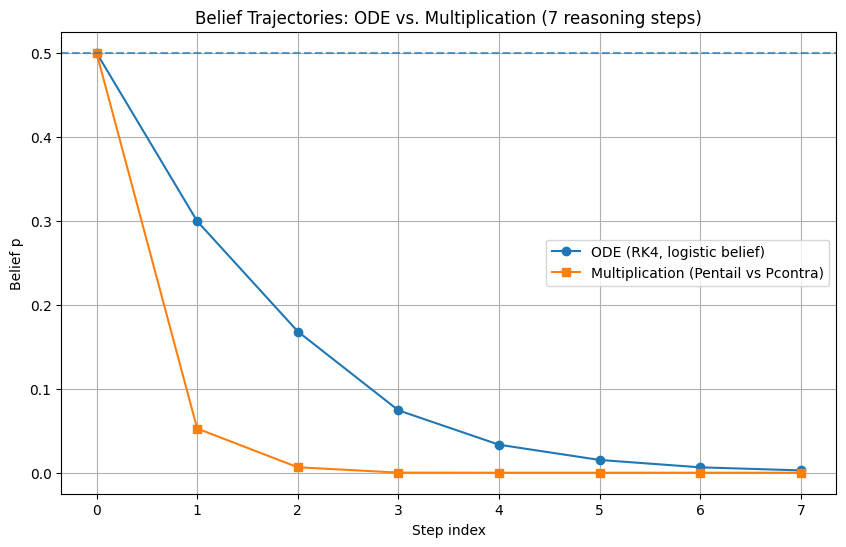

In [ ]:
#consistently contradictive

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Synthetic NLI signals for 7 reasoning steps: (entail, contra, neutral)
nli_signals = [
    (0.05, 0.9, 0.05),
    (0.1, 0.85, 0.05),
    (0.02, 0.95, 0.03),
    (0.05, 0.9, 0.05),
    (0.07, 0.88, 0.05),
    (0.04, 0.92, 0.04),
    (0.05, 0.9, 0.05),
]

# ---------------- ODE / RK4 method ----------------
def ode_rhs(p, S, r=2.0):
    return r * (S - 0.5) * p * (1 - p)

def rk4_step(p, S, dt=1.0, r=2.0):
    k1 = ode_rhs(p, S, r)
    k2 = ode_rhs(p + 0.5*dt*k1, S, r)
    k3 = ode_rhs(p + 0.5*dt*k2, S, r)
    k4 = ode_rhs(p + dt*k3, S, r)
    return p + (dt/6.0)*(k1 + 2*k2 + 2*k3 + k4)

def run_ode(nli_signals, r=2.0, dt=1.0, p0=0.5):
    p_values = [p0]
    p = p0
    S_values = []
    for e, c, _ in nli_signals:
        S_raw = e - c
        S = (S_raw + 1) / 2.0
        S_values.append(S)
        p = rk4_step(p, S, dt, r)
        p_values.append(p)
    return np.array(p_values), np.array(S_values)

# ---------------- Multiplicative (Bayesian style) ----------------
def run_multiplication(nli_signals, p0=0.5):
    Pentail, Pcontra = 1.0, 1.0
    p_values = [p0]

    for e, c, _ in nli_signals:
        Pentail *= e
        Pcontra *= c if c > 0 else 1e-6  # avoid zero collapse
        denom = Pentail + Pcontra
        p = Pentail / denom if denom > 0 else 0.5
        p_values.append(p)

    return np.array(p_values)

# ---------------- Main ----------------
if __name__ == "__main__":
    ode_traj, S_vals = run_ode(nli_signals, r=2.0, dt=1.0, p0=0.5)
    mult_traj = run_multiplication(nli_signals, p0=0.5)

    steps = np.arange(0, len(nli_signals) + 1)
    table = pd.DataFrame({
        "step": steps,
        "S_i (ODE)": np.concatenate([[np.nan], S_vals]),
        "p_ODE": ode_traj,
        "p_multiplication": mult_traj,
    })
    print(table.round(4).to_string(index=False))

    plt.figure(figsize=(10,6))
    plt.plot(steps, ode_traj, marker="o", label="ODE (RK4, logistic belief)")
    plt.plot(steps, mult_traj, marker="s", label="Multiplication (Pentail vs Pcontra)")
    plt.axhline(0.5, linestyle="--", alpha=0.7)
    plt.title("Belief Trajectories: ODE vs. Multiplication (7 reasoning steps)")
    plt.xlabel("Step index")
    plt.ylabel("Belief p")
    plt.legend()
    plt.grid(True)
    plt.show()

 step  S_i (ODE)  p_ODE  p_multiplication
    0        NaN 0.5000            0.5000
    1      0.500 0.5000            0.5000
    2      0.505 0.5025            0.5075
    3      0.500 0.5025            0.5075
    4      0.495 0.5000            0.5000
    5      0.505 0.5025            0.5075
    6      0.500 0.5025            0.5075
    7      0.505 0.5050            0.5149


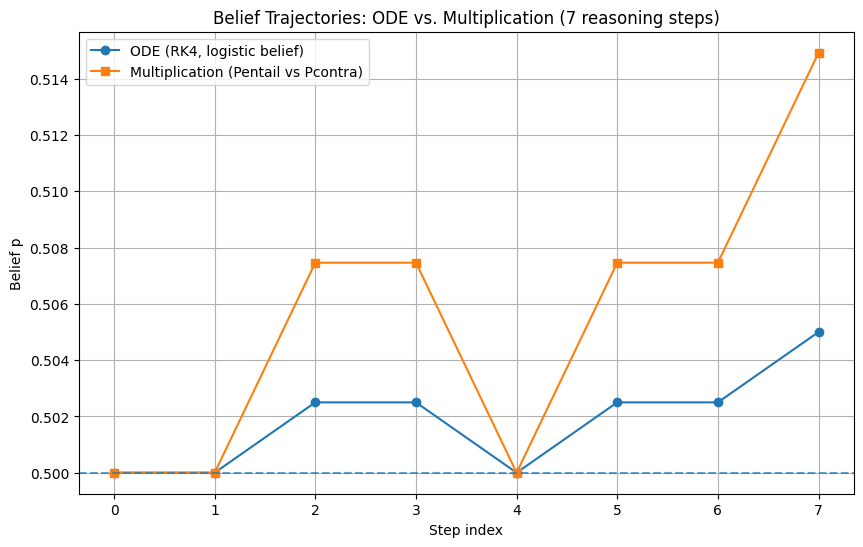

In [ ]:
#unverifiable

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Synthetic NLI signals for 7 reasoning steps: (entail, contra, neutral)
nli_signals = [
    (0.33, 0.33, 0.34),
    (0.34, 0.33, 0.33),
    (0.32, 0.32, 0.36),
    (0.33, 0.34, 0.33),
    (0.34, 0.33, 0.33),
    (0.33, 0.33, 0.34),
    (0.34, 0.33, 0.33),
]

# ---------------- ODE / RK4 method ----------------
def ode_rhs(p, S, r=2.0):
    return r * (S - 0.5) * p * (1 - p)

def rk4_step(p, S, dt=1.0, r=2.0):
    k1 = ode_rhs(p, S, r)
    k2 = ode_rhs(p + 0.5*dt*k1, S, r)
    k3 = ode_rhs(p + 0.5*dt*k2, S, r)
    k4 = ode_rhs(p + dt*k3, S, r)
    return p + (dt/6.0)*(k1 + 2*k2 + 2*k3 + k4)

def run_ode(nli_signals, r=2.0, dt=1.0, p0=0.5):
    p_values = [p0]
    p = p0
    S_values = []
    for e, c, _ in nli_signals:
        S_raw = e - c
        S = (S_raw + 1) / 2.0
        S_values.append(S)
        p = rk4_step(p, S, dt, r)
        p_values.append(p)
    return np.array(p_values), np.array(S_values)

# ---------------- Multiplicative (Bayesian style) ----------------
def run_multiplication(nli_signals, p0=0.5):
    Pentail, Pcontra = 1.0, 1.0
    p_values = [p0]

    for e, c, _ in nli_signals:
        Pentail *= e
        Pcontra *= c if c > 0 else 1e-6  # avoid zero collapse
        denom = Pentail + Pcontra
        p = Pentail / denom if denom > 0 else 0.5
        p_values.append(p)

    return np.array(p_values)

# ---------------- Main ----------------
if __name__ == "__main__":
    ode_traj, S_vals = run_ode(nli_signals, r=2.0, dt=1.0, p0=0.5)
    mult_traj = run_multiplication(nli_signals, p0=0.5)

    steps = np.arange(0, len(nli_signals) + 1)
    table = pd.DataFrame({
        "step": steps,
        "S_i (ODE)": np.concatenate([[np.nan], S_vals]),
        "p_ODE": ode_traj,
        "p_multiplication": mult_traj,
    })
    print(table.round(4).to_string(index=False))

    plt.figure(figsize=(10,6))
    plt.plot(steps, ode_traj, marker="o", label="ODE (RK4, logistic belief)")
    plt.plot(steps, mult_traj, marker="s", label="Multiplication (Pentail vs Pcontra)")
    plt.axhline(0.5, linestyle="--", alpha=0.7)
    plt.title("Belief Trajectories: ODE vs. Multiplication (7 reasoning steps)")
    plt.xlabel("Step index")
    plt.ylabel("Belief p")
    plt.legend()
    plt.grid(True)
    plt.show()

 step  S_i (ODE)  p_ODE  p_multiplication
    0        NaN 0.5000            0.5000
    1      0.850 0.6682            0.8889
    2      0.450 0.6456            0.8000
    3      0.450 0.6224            0.7619
    4      0.250 0.5000            0.4776
    5      0.650 0.5744            0.6465
    6      0.550 0.5987            0.8458
    7      0.875 0.7594            0.9790


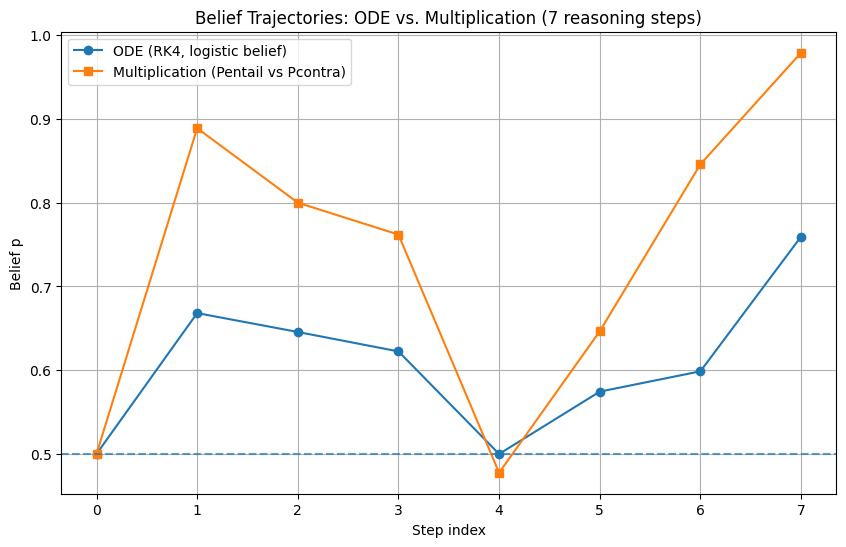

In [ ]:
#consistently flipping

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Synthetic NLI signals for 7 reasoning steps: (entail, contra, neutral)
nli_signals = [
    (0.8, 0.1, 0.1),
    (0.1, 0.2, 0.7),
    (0.4, 0.5, 0.1),
    (0.2, 0.7, 0.1),
    (0.6, 0.3, 0.1),
    (0.15, 0.05, 0.8),
    (0.85, 0.1, 0.05),
]

# ---------------- ODE / RK4 method ----------------
def ode_rhs(p, S, r=2.0):
    return r * (S - 0.5) * p * (1 - p)

def rk4_step(p, S, dt=1.0, r=2.0):
    k1 = ode_rhs(p, S, r)
    k2 = ode_rhs(p + 0.5*dt*k1, S, r)
    k3 = ode_rhs(p + 0.5*dt*k2, S, r)
    k4 = ode_rhs(p + dt*k3, S, r)
    return p + (dt/6.0)*(k1 + 2*k2 + 2*k3 + k4)

def run_ode(nli_signals, r=2.0, dt=1.0, p0=0.5):
    p_values = [p0]
    p = p0
    S_values = []
    for e, c, _ in nli_signals:
        S_raw = e - c
        S = (S_raw + 1) / 2.0
        S_values.append(S)
        p = rk4_step(p, S, dt, r)
        p_values.append(p)
    return np.array(p_values), np.array(S_values)

# ---------------- Multiplicative (Bayesian style) ----------------
def run_multiplication(nli_signals, p0=0.5):
    Pentail, Pcontra = 1.0, 1.0
    p_values = [p0]

    for e, c, _ in nli_signals:
        Pentail *= e
        Pcontra *= c if c > 0 else 1e-6  # avoid zero collapse
        denom = Pentail + Pcontra
        p = Pentail / denom if denom > 0 else 0.5
        p_values.append(p)

    return np.array(p_values)

# ---------------- Main ----------------
if __name__ == "__main__":
    ode_traj, S_vals = run_ode(nli_signals, r=2.0, dt=1.0, p0=0.5)
    mult_traj = run_multiplication(nli_signals, p0=0.5)

    steps = np.arange(0, len(nli_signals) + 1)
    table = pd.DataFrame({
        "step": steps,
        "S_i (ODE)": np.concatenate([[np.nan], S_vals]),
        "p_ODE": ode_traj,
        "p_multiplication": mult_traj,
    })
    print(table.round(4).to_string(index=False))

    plt.figure(figsize=(10,6))
    plt.plot(steps, ode_traj, marker="o", label="ODE (RK4, logistic belief)")
    plt.plot(steps, mult_traj, marker="s", label="Multiplication (Pentail vs Pcontra)")
    plt.axhline(0.5, linestyle="--", alpha=0.7)
    plt.title("Belief Trajectories: ODE vs. Multiplication (7 reasoning steps)")
    plt.xlabel("Step index")
    plt.ylabel("Belief p")
    plt.legend()
    plt.grid(True)
    plt.show()

 step  S_i (ODE)  p_ODE  p_multiplication
    0        NaN 0.5000            0.5000
    1      0.650 0.5744            0.6667
    2      0.350 0.5000            0.5000
    3      0.750 0.6225            0.7778
    4      0.275 0.5125            0.5556
    5      0.700 0.6106            0.7647
    6      0.350 0.5374            0.6190
    7      0.725 0.6457            0.8198


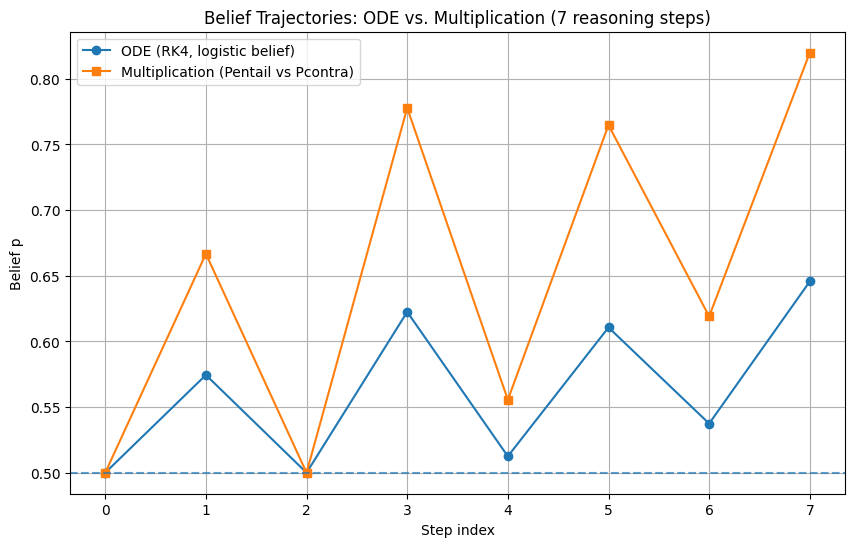

In [ ]:
#oscillating

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Synthetic NLI signals for 7 reasoning steps: (entail, contra, neutral)
nli_signals = [
    (0.6, 0.3, 0.1),
    (0.3, 0.6, 0.1),
    (0.7, 0.2, 0.1),
    (0.25, 0.7, 0.05),
    (0.65, 0.25, 0.1),
    (0.3, 0.6, 0.1),
    (0.7, 0.25, 0.05),
]

# ---------------- ODE / RK4 method ----------------
def ode_rhs(p, S, r=2.0):
    return r * (S - 0.5) * p * (1 - p)

def rk4_step(p, S, dt=1.0, r=2.0):
    k1 = ode_rhs(p, S, r)
    k2 = ode_rhs(p + 0.5*dt*k1, S, r)
    k3 = ode_rhs(p + 0.5*dt*k2, S, r)
    k4 = ode_rhs(p + dt*k3, S, r)
    return p + (dt/6.0)*(k1 + 2*k2 + 2*k3 + k4)

def run_ode(nli_signals, r=2.0, dt=1.0, p0=0.5):
    p_values = [p0]
    p = p0
    S_values = []
    for e, c, _ in nli_signals:
        S_raw = e - c
        S = (S_raw + 1) / 2.0
        S_values.append(S)
        p = rk4_step(p, S, dt, r)
        p_values.append(p)
    return np.array(p_values), np.array(S_values)

# ---------------- Multiplicative (Bayesian style) ----------------
def run_multiplication(nli_signals, p0=0.5):
    Pentail, Pcontra = 1.0, 1.0
    p_values = [p0]

    for e, c, _ in nli_signals:
        Pentail *= e
        Pcontra *= c if c > 0 else 1e-6  # avoid zero collapse
        denom = Pentail + Pcontra
        p = Pentail / denom if denom > 0 else 0.5
        p_values.append(p)

    return np.array(p_values)

# ---------------- Main ----------------
if __name__ == "__main__":
    ode_traj, S_vals = run_ode(nli_signals, r=2.0, dt=1.0, p0=0.5)
    mult_traj = run_multiplication(nli_signals, p0=0.5)

    steps = np.arange(0, len(nli_signals) + 1)
    table = pd.DataFrame({
        "step": steps,
        "S_i (ODE)": np.concatenate([[np.nan], S_vals]),
        "p_ODE": ode_traj,
        "p_multiplication": mult_traj,
    })
    print(table.round(4).to_string(index=False))

    plt.figure(figsize=(10,6))
    plt.plot(steps, ode_traj, marker="o", label="ODE (RK4, logistic belief)")
    plt.plot(steps, mult_traj, marker="s", label="Multiplication (Pentail vs Pcontra)")
    plt.axhline(0.5, linestyle="--", alpha=0.7)
    plt.title("Belief Trajectories: ODE vs. Multiplication (7 reasoning steps)")
    plt.xlabel("Step index")
    plt.ylabel("Belief p")
    plt.legend()
    plt.grid(True)
    plt.show()

 step  S_i (ODE)  p_ODE  p_multiplication
    0        NaN 0.5000            0.5000
    1       0.85 0.6682            0.8889
    2       0.75 0.7685            0.9655
    3       0.65 0.8175            0.9825
    4       0.55 0.8320            0.9859
    5       0.45 0.8175            0.9825
    6       0.35 0.7685            0.9655
    7       0.25 0.6682            0.8889


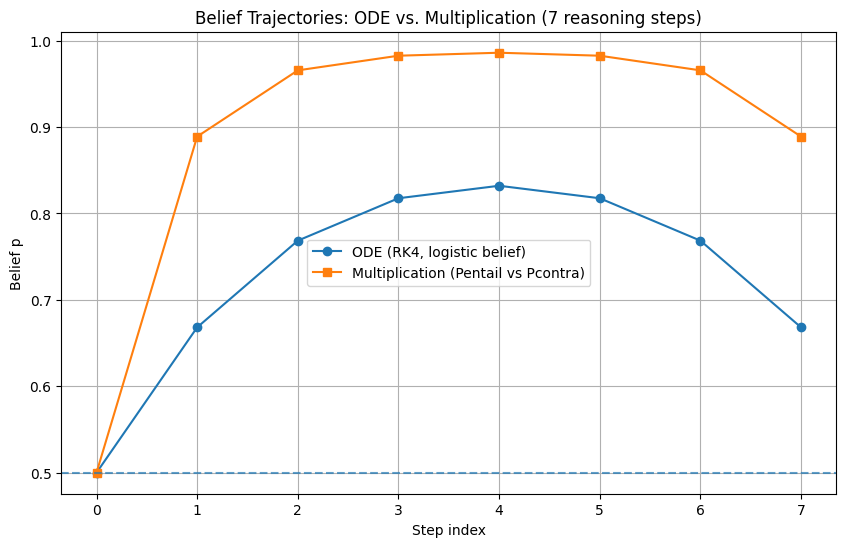

In [ ]:
#gradual drift from support to contradiction

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Synthetic NLI signals for 7 reasoning steps: (entail, contra, neutral)
nli_signals = [
    (0.8, 0.1, 0.1),
    (0.7, 0.2, 0.1),
    (0.6, 0.3, 0.1),
    (0.5, 0.4, 0.1),
    (0.4, 0.5, 0.1),
    (0.3, 0.6, 0.1),
    (0.2, 0.7, 0.1),
]

# ---------------- ODE / RK4 method ----------------
def ode_rhs(p, S, r=2.0):
    return r * (S - 0.5) * p * (1 - p)

def rk4_step(p, S, dt=1.0, r=2.0):
    k1 = ode_rhs(p, S, r)
    k2 = ode_rhs(p + 0.5*dt*k1, S, r)
    k3 = ode_rhs(p + 0.5*dt*k2, S, r)
    k4 = ode_rhs(p + dt*k3, S, r)
    return p + (dt/6.0)*(k1 + 2*k2 + 2*k3 + k4)

def run_ode(nli_signals, r=2.0, dt=1.0, p0=0.5):
    p_values = [p0]
    p = p0
    S_values = []
    for e, c, _ in nli_signals:
        S_raw = e - c
        S = (S_raw + 1) / 2.0
        S_values.append(S)
        p = rk4_step(p, S, dt, r)
        p_values.append(p)
    return np.array(p_values), np.array(S_values)

# ---------------- Multiplicative (Bayesian style) ----------------
def run_multiplication(nli_signals, p0=0.5):
    Pentail, Pcontra = 1.0, 1.0
    p_values = [p0]

    for e, c, _ in nli_signals:
        Pentail *= e
        Pcontra *= c if c > 0 else 1e-6  # avoid zero collapse
        denom = Pentail + Pcontra
        p = Pentail / denom if denom > 0 else 0.5
        p_values.append(p)

    return np.array(p_values)

# ---------------- Main ----------------
if __name__ == "__main__":
    ode_traj, S_vals = run_ode(nli_signals, r=2.0, dt=1.0, p0=0.5)
    mult_traj = run_multiplication(nli_signals, p0=0.5)

    steps = np.arange(0, len(nli_signals) + 1)
    table = pd.DataFrame({
        "step": steps,
        "S_i (ODE)": np.concatenate([[np.nan], S_vals]),
        "p_ODE": ode_traj,
        "p_multiplication": mult_traj,
    })
    print(table.round(4).to_string(index=False))

    plt.figure(figsize=(10,6))
    plt.plot(steps, ode_traj, marker="o", label="ODE (RK4, logistic belief)")
    plt.plot(steps, mult_traj, marker="s", label="Multiplication (Pentail vs Pcontra)")
    plt.axhline(0.5, linestyle="--", alpha=0.7)
    plt.title("Belief Trajectories: ODE vs. Multiplication (7 reasoning steps)")
    plt.xlabel("Step index")
    plt.ylabel("Belief p")
    plt.legend()
    plt.grid(True)
    plt.show()

 step  S_i (ODE)  p_ODE  p_multiplication
    0        NaN 0.5000               0.5
    1        1.0 0.7309               1.0
    2        0.0 0.5000               0.0
    3        1.0 0.7309               0.0
    4        0.0 0.5001               0.0
    5        1.0 0.7310               0.0
    6        0.0 0.5001               0.0
    7        1.0 0.7310               0.0


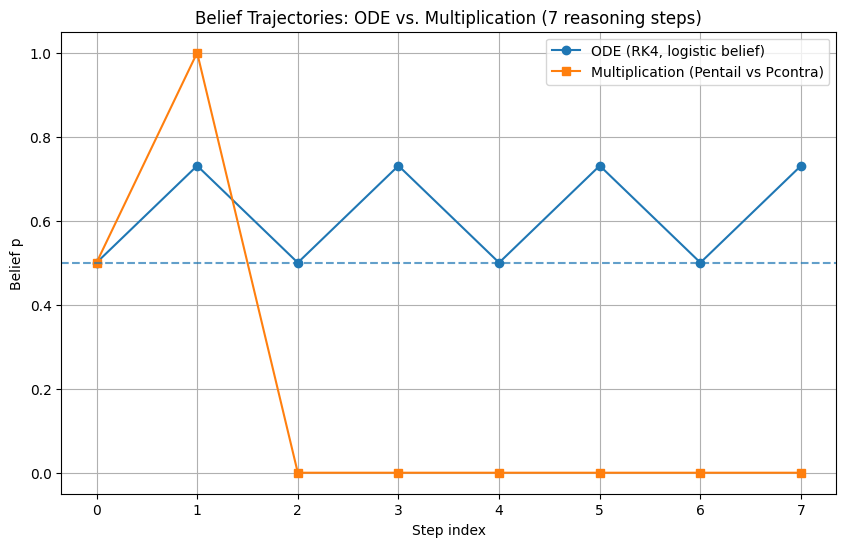

In [ ]:
#extreme certainty

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Synthetic NLI signals for 7 reasoning steps: (entail, contra, neutral)
nli_signals = [
    (1.0, 0.0, 0.0),  # pure entailment
    (0.0, 1.0, 0.0),  # pure contradiction
    (1.0, 0.0, 0.0),
    (0.0, 1.0, 0.0),
    (1.0, 0.0, 0.0),
    (0.0, 1.0, 0.0),
    (1.0, 0.0, 0.0),
]

# ---------------- ODE / RK4 method ----------------
def ode_rhs(p, S, r=2.0):
    return r * (S - 0.5) * p * (1 - p)

def rk4_step(p, S, dt=1.0, r=2.0):
    k1 = ode_rhs(p, S, r)
    k2 = ode_rhs(p + 0.5*dt*k1, S, r)
    k3 = ode_rhs(p + 0.5*dt*k2, S, r)
    k4 = ode_rhs(p + dt*k3, S, r)
    return p + (dt/6.0)*(k1 + 2*k2 + 2*k3 + k4)

def run_ode(nli_signals, r=2.0, dt=1.0, p0=0.5):
    p_values = [p0]
    p = p0
    S_values = []
    for e, c, _ in nli_signals:
        S_raw = e - c
        S = (S_raw + 1) / 2.0
        S_values.append(S)
        p = rk4_step(p, S, dt, r)
        p_values.append(p)
    return np.array(p_values), np.array(S_values)

# ---------------- Multiplicative (Bayesian style) ----------------
def run_multiplication(nli_signals, p0=0.5):
    Pentail, Pcontra = 1.0, 1.0
    p_values = [p0]

    for e, c, _ in nli_signals:
        Pentail *= e
        Pcontra *= c if c > 0 else 1e-6  # avoid zero collapse
        denom = Pentail + Pcontra
        p = Pentail / denom if denom > 0 else 0.5
        p_values.append(p)

    return np.array(p_values)

# ---------------- Main ----------------
if __name__ == "__main__":
    ode_traj, S_vals = run_ode(nli_signals, r=2.0, dt=1.0, p0=0.5)
    mult_traj = run_multiplication(nli_signals, p0=0.5)

    steps = np.arange(0, len(nli_signals) + 1)
    table = pd.DataFrame({
        "step": steps,
        "S_i (ODE)": np.concatenate([[np.nan], S_vals]),
        "p_ODE": ode_traj,
        "p_multiplication": mult_traj,
    })
    print(table.round(4).to_string(index=False))

    plt.figure(figsize=(10,6))
    plt.plot(steps, ode_traj, marker="o", label="ODE (RK4, logistic belief)")
    plt.plot(steps, mult_traj, marker="s", label="Multiplication (Pentail vs Pcontra)")
    plt.axhline(0.5, linestyle="--", alpha=0.7)
    plt.title("Belief Trajectories: ODE vs. Multiplication (7 reasoning steps)")
    plt.xlabel("Step index")
    plt.ylabel("Belief p")
    plt.legend()
    plt.grid(True)
    plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------- ODE / RK4 method ----------------
def ode_rhs(p, S, r=2.0):
    return r * (S - 0.5) * p * (1 - p)

def rk4_step(p, S, dt=1.0, r=2.0):
    k1 = ode_rhs(p, S, r)
    k2 = ode_rhs(p + 0.5*dt*k1, S, r)
    k3 = ode_rhs(p + 0.5*dt*k2, S, r)
    k4 = ode_rhs(p + dt*k3, S, r)
    return p + (dt/6.0)*(k1 + 2*k2 + 2*k3 + k4)

def run_ode(nli_signals, r=2.0, dt=1.0, p0=0.5):
    p_values = [p0]
    p = p0
    for e, c, _ in nli_signals:
        S_raw = e - c
        S = (S_raw + 1) / 2.0
        p = rk4_step(p, S, dt, r)
        p_values.append(p)
    return np.array(p_values)

# ---------------- Multiplicative (Bayesian style) ----------------
def run_multiplication(nli_signals, p0=0.5):
    Pentail, Pcontra = 1.0, 1.0
    p_values = [p0]
    for e, c, _ in nli_signals:
        Pentail *= e
        Pcontra *= c if c > 0 else 1e-6
        denom = Pentail + Pcontra
        p = Pentail / denom if denom > 0 else 0.5
        p_values.append(p)
    return np.array(p_values)

# ---------------- Scenarios ----------------
scenarios = {
    "Consistently Contradictive": [
        (0.05, 0.9, 0.05), (0.1, 0.85, 0.05), (0.02, 0.95, 0.03),
        (0.05, 0.9, 0.05), (0.07, 0.88, 0.05), (0.04, 0.92, 0.04), (0.05, 0.9, 0.05)
    ],
    "Consistently Supportive": [
        (0.9, 0.05, 0.05), (0.85, 0.1, 0.05), (0.95, 0.02, 0.03),
        (0.9, 0.05, 0.05), (0.88, 0.07, 0.05), (0.92, 0.04, 0.04), (0.9, 0.05, 0.05)
    ],
    "Unverifiable": [
        (0.33, 0.33, 0.34), (0.34, 0.33, 0.33), (0.32, 0.32, 0.36),
        (0.33, 0.34, 0.33), (0.34, 0.33, 0.33), (0.33, 0.33, 0.34), (0.34, 0.33, 0.33)
    ],
    "Consistently Flipping": [
        (0.8, 0.1, 0.1), (0.1, 0.2, 0.7), (0.4, 0.5, 0.1),
        (0.2, 0.7, 0.1), (0.6, 0.3, 0.1), (0.15, 0.05, 0.8), (0.85, 0.1, 0.05)
    ],
    "Oscillating": [
        (0.6, 0.3, 0.1), (0.3, 0.6, 0.1), (0.7, 0.2, 0.1),
        (0.25, 0.7, 0.05), (0.65, 0.25, 0.1), (0.3, 0.6, 0.1), (0.7, 0.25, 0.05)
    ],
    "Gradual Drift": [
        (0.8, 0.1, 0.1), (0.7, 0.2, 0.1), (0.6, 0.3, 0.1),
        (0.5, 0.4, 0.1), (0.4, 0.5, 0.1), (0.3, 0.6, 0.1), (0.2, 0.7, 0.1)
    ],
    "Extreme Certainty": [
        (1.0, 0.0, 0.0), (0.0, 1.0, 0.0), (1.0, 0.0, 0.0),
        (0.0, 1.0, 0.0), (1.0, 0.0, 0.0), (0.0, 1.0, 0.0), (1.0, 0.0, 0.0)
    ]
}

# ---------------- Plotting ----------------
plt.style.use("seaborn-whitegrid")
fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.flatten()

colors = ["#1f77b4", "#ff7f0e"]  # Blue & Orange

for idx, (title, signals) in enumerate(scenarios.items()):
    ode_traj = run_ode(signals, r=2.0, dt=1.0, p0=0.5)
    mult_traj = run_multiplication(signals, p0=0.5)
    steps = np.arange(0, len(signals) + 1)

    ax = axes[idx]
    ax.plot(steps, ode_traj, marker="o", color=colors[0], label="ODE (RK4)")
    ax.plot(steps, mult_traj, marker="s", color=colors[1], label="Multiplication")
    ax.axhline(0.5, linestyle="--", color="gray", alpha=0.7)
    ax.set_title(title, fontsize=14, fontweight="bold")
    ax.set_xlabel("Step", fontsize=12)
    ax.set_ylabel("Belief p", fontsize=12)
    ax.tick_params(axis="both", labelsize=10)
    ax.grid(True, alpha=0.3)

# Remove unused subplot
for j in range(len(scenarios), len(axes)):
    fig.delaxes(axes[j])

# Shared legend outside
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="center right", fontsize=12)

plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.suptitle("Belief Trajectories Across Scenarios", fontsize=16, fontweight="bold")
plt.savefig("belief_trajectories.png", dpi=300)
plt.show()

OSError: 'seaborn-whitegrid' is not a valid package style, path of style file, URL of style file, or library style name (library styles are listed in `style.available`)

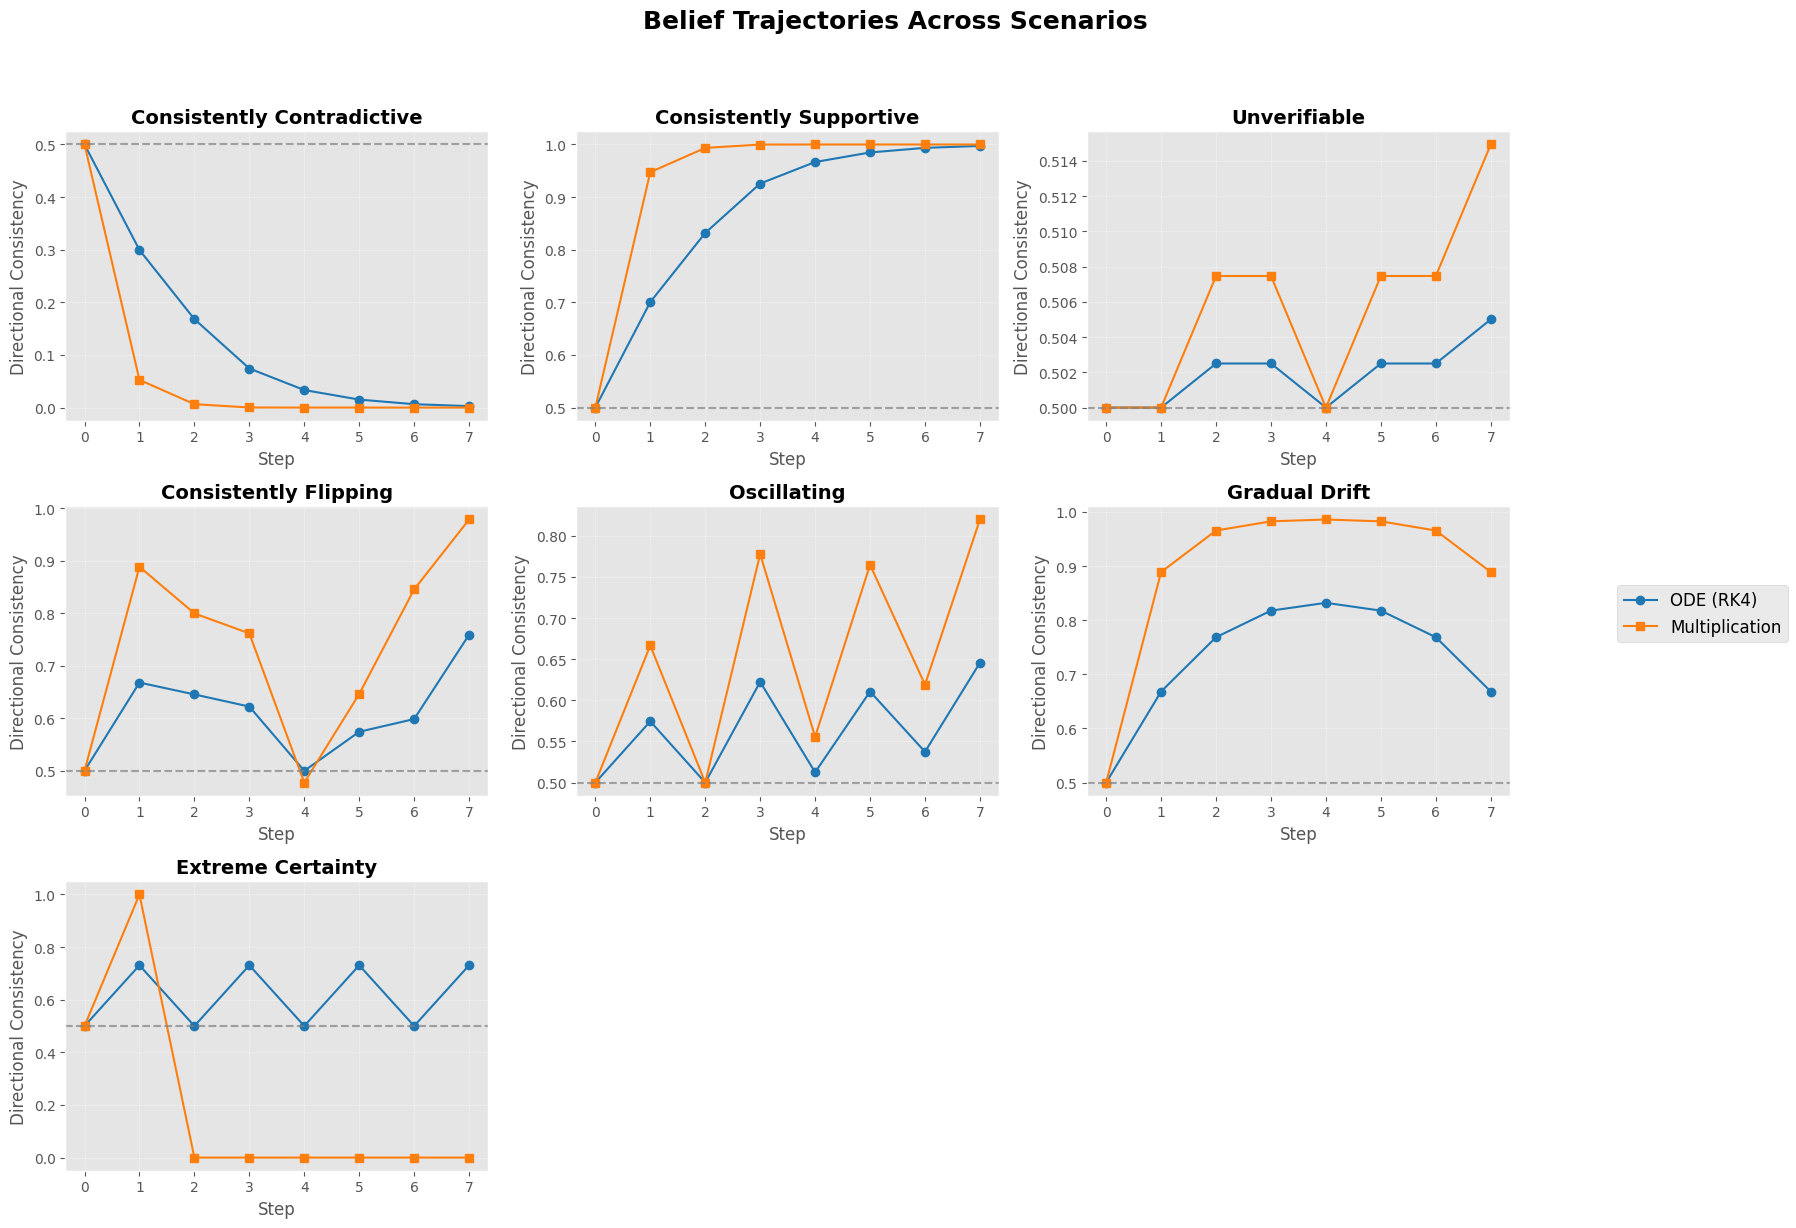

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------- ODE / RK4 method ----------------
def ode_rhs(p, S, r=2.0):
    return r * (S - 0.5) * p * (1 - p)

def rk4_step(p, S, dt=1.0, r=2.0):
    k1 = ode_rhs(p, S, r)
    k2 = ode_rhs(p + 0.5*dt*k1, S, r)
    k3 = ode_rhs(p + 0.5*dt*k2, S, r)
    k4 = ode_rhs(p + dt*k3, S, r)
    return p + (dt/6.0)*(k1 + 2*k2 + 2*k3 + k4)

def run_ode(nli_signals, r=2.0, dt=1.0, p0=0.5):
    p_values = [p0]
    p = p0
    for e, c, _ in nli_signals:
        S_raw = e - c
        S = (S_raw + 1) / 2.0
        p = rk4_step(p, S, dt, r)
        p_values.append(p)
    return np.array(p_values)

# ---------------- Multiplicative (Bayesian style) ----------------
def run_multiplication(nli_signals, p0=0.5):
    Pentail, Pcontra = 1.0, 1.0
    p_values = [p0]
    for e, c, _ in nli_signals:
        Pentail *= e
        Pcontra *= c if c > 0 else 1e-6
        denom = Pentail + Pcontra
        p = Pentail / denom if denom > 0 else 0.5
        p_values.append(p)
    return np.array(p_values)

# ---------------- Scenarios ----------------
scenarios = {
    "Consistently Contradictive": [
        (0.05, 0.9, 0.05), (0.1, 0.85, 0.05), (0.02, 0.95, 0.03),
        (0.05, 0.9, 0.05), (0.07, 0.88, 0.05), (0.04, 0.92, 0.04), (0.05, 0.9, 0.05)
    ],
    "Consistently Supportive": [
        (0.9, 0.05, 0.05), (0.85, 0.1, 0.05), (0.95, 0.02, 0.03),
        (0.9, 0.05, 0.05), (0.88, 0.07, 0.05), (0.92, 0.04, 0.04), (0.9, 0.05, 0.05)
    ],
    "Unverifiable": [
        (0.33, 0.33, 0.34), (0.34, 0.33, 0.33), (0.32, 0.32, 0.36),
        (0.33, 0.34, 0.33), (0.34, 0.33, 0.33), (0.33, 0.33, 0.34), (0.34, 0.33, 0.33)
    ],
    "Consistently Flipping": [
        (0.8, 0.1, 0.1), (0.1, 0.2, 0.7), (0.4, 0.5, 0.1),
        (0.2, 0.7, 0.1), (0.6, 0.3, 0.1), (0.15, 0.05, 0.8), (0.85, 0.1, 0.05)
    ],
    "Oscillating": [
        (0.6, 0.3, 0.1), (0.3, 0.6, 0.1), (0.7, 0.2, 0.1),
        (0.25, 0.7, 0.05), (0.65, 0.25, 0.1), (0.3, 0.6, 0.1), (0.7, 0.25, 0.05)
    ],
    "Gradual Drift": [
        (0.8, 0.1, 0.1), (0.7, 0.2, 0.1), (0.6, 0.3, 0.1),
        (0.5, 0.4, 0.1), (0.4, 0.5, 0.1), (0.3, 0.6, 0.1), (0.2, 0.7, 0.1)
    ],
    "Extreme Certainty": [
        (1.0, 0.0, 0.0), (0.0, 1.0, 0.0), (1.0, 0.0, 0.0),
        (0.0, 1.0, 0.0), (1.0, 0.0, 0.0), (0.0, 1.0, 0.0), (1.0, 0.0, 0.0)
    ]
}

# ---------------- Plotting ----------------
plt.style.use("ggplot")  # Safe built-in style

fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.flatten()

colors = ["#1f77b4", "#ff7f0e"]  # Blue & Orange

for idx, (title, signals) in enumerate(scenarios.items()):
    ode_traj = run_ode(signals, r=2.0, dt=1.0, p0=0.5)
    mult_traj = run_multiplication(signals, p0=0.5)
    steps = np.arange(0, len(signals) + 1)

    ax = axes[idx]
    ax.plot(steps, ode_traj, marker="o", color=colors[0], label="ODE (RK4)")
    ax.plot(steps, mult_traj, marker="s", color=colors[1], label="Multiplication")
    ax.axhline(0.5, linestyle="--", color="gray", alpha=0.7)
    ax.set_title(title, fontsize=14, fontweight="bold")
    ax.set_xlabel("Step", fontsize=12)
    ax.set_ylabel("Directional Consistency", fontsize=12)
    ax.tick_params(axis="both", labelsize=10)
    ax.grid(True, alpha=0.3)

# Remove unused subplot
for j in range(len(scenarios), len(axes)):
    fig.delaxes(axes[j])

# Shared legend outside
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="center right", fontsize=12)

plt.tight_layout(rect=[0, 0, 0.85, 0.95])  # leave space at top
plt.suptitle("Belief Trajectories Across Scenarios", fontsize=18, fontweight="bold", y=1.02)

plt.savefig("belief_trajectories.png", dpi=600, bbox_inches="tight")
plt.show()

# # ---------------- Plotting ----------------
# plt.style.use("ggplot")  # Safe built-in style

# fig, axes = plt.subplots(3, 3, figsize=(18, 12))
# axes = axes.flatten()

# colors = ["#1f77b4", "#ff7f0e"]  # Blue & Orange

# for idx, (title, signals) in enumerate(scenarios.items()):
#     ode_traj = run_ode(signals, r=2.0, dt=1.0, p0=0.5)
#     mult_traj = run_multiplication(signals, p0=0.5)
#     steps = np.arange(0, len(signals) + 1)

#     ax = axes[idx]
#     ax.plot(steps, ode_traj, marker="o", color=colors[0], label="ODE (RK4)")
#     ax.plot(steps, mult_traj, marker="s", color=colors[1], label="Multiplication")
#     ax.axhline(0.5, linestyle="--", color="gray", alpha=0.7)
#     ax.set_title(title, fontsize=14, fontweight="bold")
#     ax.set_xlabel("Step", fontsize=12)
#     ax.set_ylabel("Belief p", fontsize=12)
#     ax.tick_params(axis="both", labelsize=10)
#     ax.grid(True, alpha=0.3)

# # Remove unused subplot
# for j in range(len(scenarios), len(axes)):
#     fig.delaxes(axes[j])

# # Shared legend outside
# handles, labels = axes[0].get_legend_handles_labels()
# fig.legend(handles, labels, loc="center right", fontsize=12)

# plt.tight_layout(rect=[0, 0, 0.85, 1])
# plt.suptitle("Belief Trajectories Across Scenarios", fontsize=16, fontweight="bold")
# plt.savefig("belief_trajectories.png", dpi=300)
# plt.show()

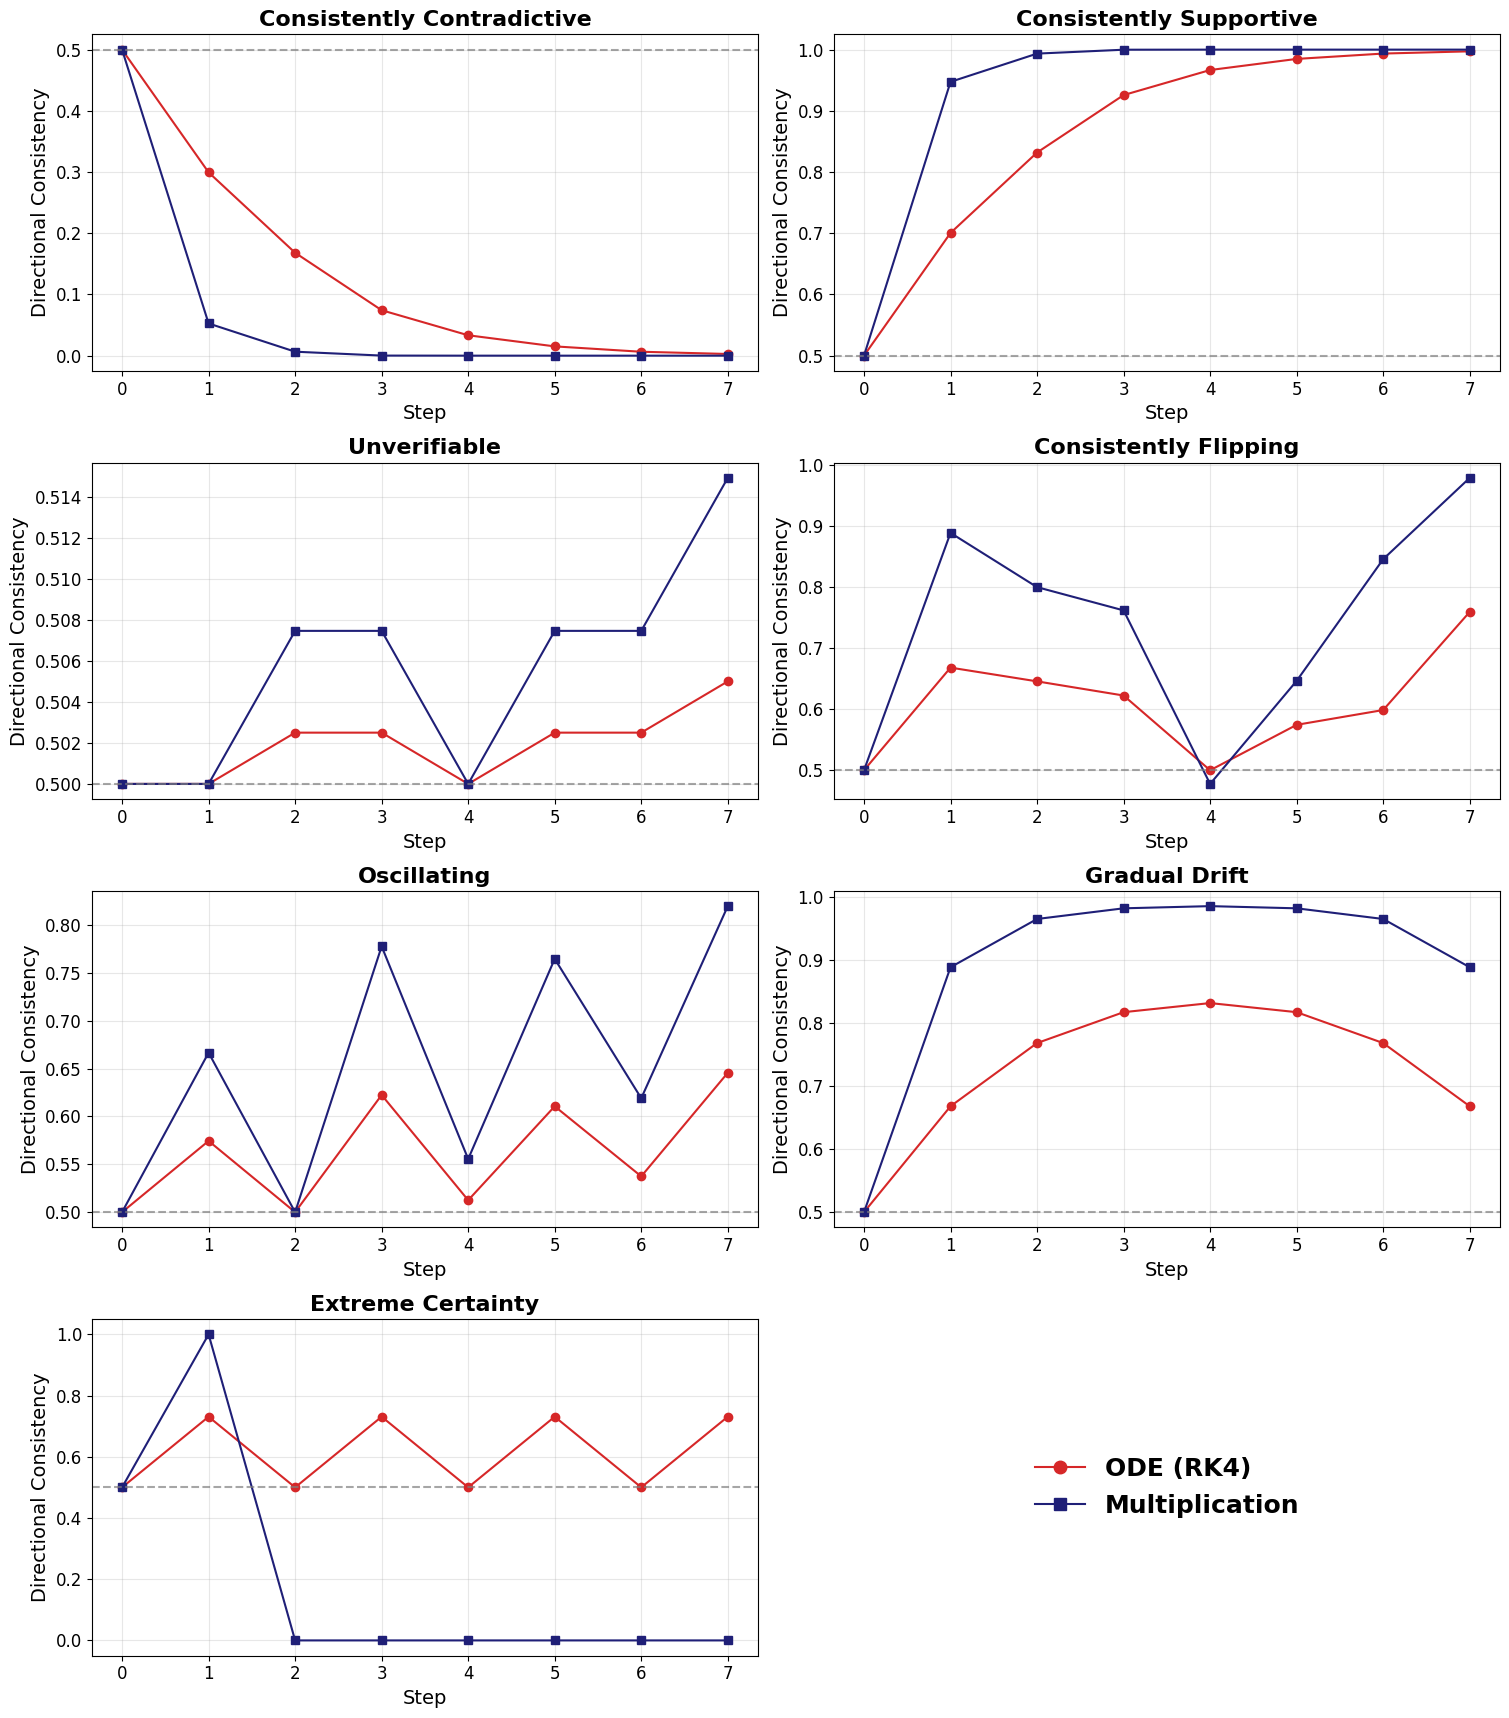

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------- ODE / RK4 method ----------------
def ode_rhs(p, S, r=2.0):
    return r * (S - 0.5) * p * (1 - p)

def rk4_step(p, S, dt=1.0, r=2.0):
    k1 = ode_rhs(p, S, r)
    k2 = ode_rhs(p + 0.5*dt*k1, S, r)
    k3 = ode_rhs(p + 0.5*dt*k2, S, r)
    k4 = ode_rhs(p + dt*k3, S, r)
    return p + (dt/6.0)*(k1 + 2*k2 + 2*k3 + k4)

def run_ode(nli_signals, r=2.0, dt=1.0, p0=0.5):
    p_values = [p0]
    p = p0
    for e, c, _ in nli_signals:
        S_raw = e - c
        S = (S_raw + 1) / 2.0
        p = rk4_step(p, S, dt, r)
        p_values.append(p)
    return np.array(p_values)

# ---------------- Multiplicative (Bayesian style) ----------------
def run_multiplication(nli_signals, p0=0.5):
    Pentail, Pcontra = 1.0, 1.0
    p_values = [p0]
    for e, c, _ in nli_signals:
        Pentail *= e
        Pcontra *= c if c > 0 else 1e-6
        denom = Pentail + Pcontra
        p = Pentail / denom if denom > 0 else 0.5
        p_values.append(p)
    return np.array(p_values)

# ---------------- Scenarios ----------------
scenarios = {
    "Consistently Contradictive": [
        (0.05, 0.9, 0.05), (0.1, 0.85, 0.05), (0.02, 0.95, 0.03),
        (0.05, 0.9, 0.05), (0.07, 0.88, 0.05), (0.04, 0.92, 0.04), (0.05, 0.9, 0.05)
    ],
    "Consistently Supportive": [
        (0.9, 0.05, 0.05), (0.85, 0.1, 0.05), (0.95, 0.02, 0.03),
        (0.9, 0.05, 0.05), (0.88, 0.07, 0.05), (0.92, 0.04, 0.04), (0.9, 0.05, 0.05)
    ],
    "Unverifiable": [
        (0.33, 0.33, 0.34), (0.34, 0.33, 0.33), (0.32, 0.32, 0.36),
        (0.33, 0.34, 0.33), (0.34, 0.33, 0.33), (0.33, 0.33, 0.34), (0.34, 0.33, 0.33)
    ],
    "Consistently Flipping": [
        (0.8, 0.1, 0.1), (0.1, 0.2, 0.7), (0.4, 0.5, 0.1),
        (0.2, 0.7, 0.1), (0.6, 0.3, 0.1), (0.15, 0.05, 0.8), (0.85, 0.1, 0.05)
    ],
    "Oscillating": [
        (0.6, 0.3, 0.1), (0.3, 0.6, 0.1), (0.7, 0.2, 0.1),
        (0.25, 0.7, 0.05), (0.65, 0.25, 0.1), (0.3, 0.6, 0.1), (0.7, 0.25, 0.05)
    ],
    "Gradual Drift": [
        (0.8, 0.1, 0.1), (0.7, 0.2, 0.1), (0.6, 0.3, 0.1),
        (0.5, 0.4, 0.1), (0.4, 0.5, 0.1), (0.3, 0.6, 0.1), (0.2, 0.7, 0.1)
    ],
    "Extreme Certainty": [
        (1.0, 0.0, 0.0), (0.0, 1.0, 0.0), (1.0, 0.0, 0.0),
        (0.0, 1.0, 0.0), (1.0, 0.0, 0.0), (0.0, 1.0, 0.0), (1.0, 0.0, 0.0)
    ]
}

# ---------------- Plotting ----------------
plt.style.use("default")

fig, axes = plt.subplots(4, 2, figsize=(16, 18))
axes = axes.flatten()

colors = ["#d62728", "#1f1f77"]  # Blue & Orange

# Plot the first 7 scenarios
for idx, (title, signals) in enumerate(scenarios.items()):
    ode_traj = run_ode(signals, r=2.0, dt=1.0, p0=0.5)
    mult_traj = run_multiplication(signals, p0=0.5)
    steps = np.arange(0, len(signals) + 1)

    ax = axes[idx]
    ax.plot(steps, ode_traj, marker="o", color=colors[0], label="ODE (RK4)")
    ax.plot(steps, mult_traj, marker="s", color=colors[1], label="Multiplication")
    ax.axhline(0.5, linestyle="--", color="gray", alpha=0.7)
    ax.set_title(title, fontsize=16, fontweight="bold")
    ax.set_xlabel("Step", fontsize=14)
    ax.set_ylabel("Directional Consistency", fontsize=14)
    ax.tick_params(axis="both", labelsize=12)
    ax.grid(True, alpha=0.3)

# 8th subplot for the legend
axes[7].axis("off")  # turn off axes
handles, labels = axes[0].get_legend_handles_labels()
axes[7].legend(handles, labels, loc="center", fontsize=20, frameon=False, prop={"size": 18, "weight": "bold"}, markerscale=1.5)

plt.tight_layout(rect=[0, 0, 0.95, 0.96])
# plt.suptitle("Belief Trajectories Across Scenarios", fontsize=20, fontweight="bold", y=1.02)

plt.savefig("belief_trajectories_4x2_legend.pdf", dpi=2400, bbox_inches="tight")
plt.show()
